# Notebook 04 — Baseline Models

## Baseline Model Setup

This section loads all required libraries for data processing, feature extraction, model training, and evaluation. It also imports configuration variables from `config.py` to maintain consistent paths and settings across the project.

An output directory is created for saving visualisations, and plotting parameters are adjusted to ensure clear and consistent figures throughout the analysis.

In [1]:
# System path setup
import sys, os, pickle, time
sys.path.insert(0, os.path.abspath('..'))

# Core libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Sparse matrix operations
from scipy.sparse import hstack, csr_matrix

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import warnings; warnings.filterwarnings('ignore')

# Configuration
import config
from config import (
    LABELLED_DATASET,
    PLOTS_DIR,
    RANDOM_STATE,
    BEST_BASELINE_PKL,
    BASELINE_RESULTS_CSV,
)

# Create output directory
os.makedirs(PLOTS_DIR / 'baseline_model', exist_ok=True)

# Plot settings
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False
})

## Data Loading and Splitting

The processed dataset is loaded and partitioned into training, validation, and test sets using the predefined `split` column. This ensures a consistent evaluation pipeline across all models.

Labels are extracted separately for each subset to be used during model training and evaluation. The sizes of each split are printed to verify correct data distribution.

In [2]:
# Load dataset
df = pd.read_csv(LABELLED_DATASET)

# Split dataset
train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'val'].copy()
test  = df[df['split'] == 'test'].copy()

# Extract labels
y_train = train['label_id'].values
y_val   = val['label_id'].values
y_test  = test['label_id'].values

# Print dataset sizes
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

Train: 3,996  Val: 3,996  Test: 1,998


## Feature Extraction

Text features are extracted using TF-IDF with unigram and bigram representations, capturing both individual words and short phrases. The vectoriser is fitted on the training data and applied consistently to validation and test sets.

In addition, pre-computed linguistic features are identified and incorporated into the feature space. These features are converted into a sparse format and concatenated with TF-IDF vectors to form an augmented representation, enabling models to leverage both textual and linguistic signals.

In [3]:
# TF-IDF on cleaned text
tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2),
                        sublinear_tf=True, min_df=2)

X_train_tfidf = tfidf.fit_transform(train['text_clean'])
X_val_tfidf   = tfidf.transform(val['text_clean'])
X_test_tfidf  = tfidf.transform(test['text_clean'])

print(f'TF-IDF matrix: {X_train_tfidf.shape}')


# Identify linguistic feature columns
ling_cols = [c for c in ['intensifier_score', 'neg_ratio', 'intens_ratio'] if c in train.columns]
print(f'Linguistic feature columns: {ling_cols}')


# Convert linguistic features to sparse format
def ling_matrix(split):
    return csr_matrix(split[ling_cols].fillna(0).values)


# Combine TF-IDF with linguistic features
X_train_aug = hstack([X_train_tfidf, ling_matrix(train)])
X_val_aug   = hstack([X_val_tfidf,   ling_matrix(val)])
X_test_aug  = hstack([X_test_tfidf,  ling_matrix(test)])

print(f'Augmented matrix: {X_train_aug.shape}')

TF-IDF matrix: (3996, 30000)
Linguistic feature columns: ['intensifier_score']
Augmented matrix: (3996, 30001)


## Model Evaluation

This function evaluates model performance using standard classification metrics including accuracy, precision, recall, F1-score, and ROC-AUC. It also prints a detailed classification report for class-wise performance analysis.

Optionally, a confusion matrix is generated and saved to visually assess prediction behaviour across classes.

In [4]:
# Evaluate model performance and generate metrics
def evaluate_model(model, X, y_true, model_name='Model', split='val', plot=True):

    # Generate predictions
    y_pred = model.predict(X)

    # Compute evaluation metrics
    metrics = {
        'model':     model_name,
        'split':     split,
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall':    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1':        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'roc_auc':   roc_auc_score(y_true, model.predict_proba(X)[:, 1])
                     if hasattr(model, 'predict_proba') else float('nan'),
    }

    # Print classification report
    print(f'\n── {model_name} ({split}) ──')
    print(classification_report(y_true, y_pred, target_names=['non-suicide', 'suicide']))

    # Plot confusion matrix
    if plot:
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(
            confusion_matrix(y_true, y_pred),
            display_labels=['non-suicide', 'suicide']
        ).plot(ax=ax, colorbar=False, cmap='Blues')

        ax.set_title(f'{model_name} ({split})', fontweight='bold')
        plt.tight_layout()

        safe = model_name.lower().replace(' ', '_')
        plt.savefig(PLOTS_DIR / 'baseline_model' / f'cm_{safe}_{split}.png',
                    bbox_inches='tight')
        plt.show()

    return metrics

## Logistic Regression (Baseline)

A Logistic Regression model is trained using TF-IDF features to establish a strong linear baseline. The model is optimised for large sparse data using the `saga` solver and is evaluated on the validation set to measure its performance.


── Logistic Regression (val) ──
              precision    recall  f1-score   support

 non-suicide       0.89      0.92      0.90      2017
     suicide       0.91      0.89      0.90      1979

    accuracy                           0.90      3996
   macro avg       0.90      0.90      0.90      3996
weighted avg       0.90      0.90      0.90      3996



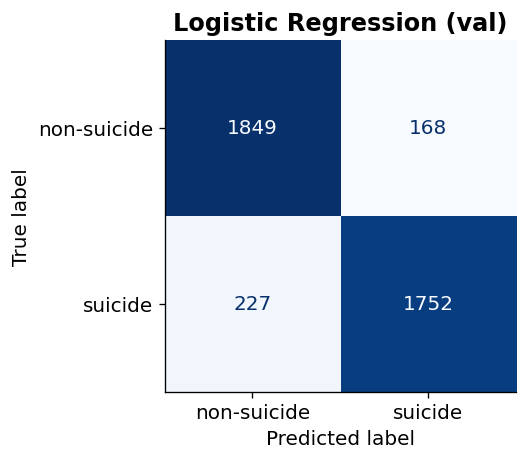

In [5]:
# Train Logistic Regression model
t0 = time.time()

lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='saga',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

lr.fit(X_train_tfidf, y_train)

# Evaluate on validation set
lr_val = evaluate_model(lr, X_val_tfidf, y_val,
                        'Logistic Regression', 'val')

## Linear SVM (Baseline)

A Linear Support Vector Machine is trained using TF-IDF features to model high-dimensional sparse text data. Since LinearSVC does not provide probability estimates, calibration is applied to enable ROC-AUC evaluation.

The model is evaluated on the validation set to compare its performance against other baselines.


── Linear SVM (val) ──
              precision    recall  f1-score   support

 non-suicide       0.92      0.92      0.92      2017
     suicide       0.91      0.92      0.92      1979

    accuracy                           0.92      3996
   macro avg       0.92      0.92      0.92      3996
weighted avg       0.92      0.92      0.92      3996



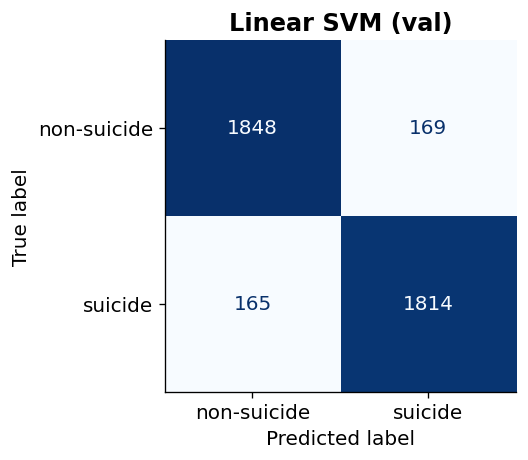

In [6]:
# Train Linear SVM with calibration
t0 = time.time()

svm = CalibratedClassifierCV(
    LinearSVC(C=0.5, max_iter=2000, random_state=RANDOM_STATE),
    cv=3
)

svm.fit(X_train_tfidf, y_train)

# Evaluate on validation set
svm_val = evaluate_model(svm, X_val_tfidf, y_val,
                         'Linear SVM', 'val')

## Random Forest (Augmented Features)

A Random Forest model is trained using the augmented feature set, combining TF-IDF representations with linguistic features. Class weighting is applied to handle class imbalance and improve performance on minority classes.

The model is evaluated on the validation set to compare its effectiveness against linear baselines.


── Random Forest (val) ──
              precision    recall  f1-score   support

 non-suicide       0.84      0.87      0.86      2017
     suicide       0.87      0.83      0.85      1979

    accuracy                           0.85      3996
   macro avg       0.85      0.85      0.85      3996
weighted avg       0.85      0.85      0.85      3996



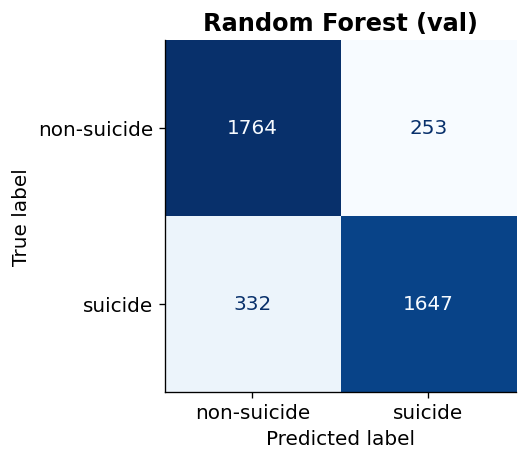

In [7]:
# Train Random Forest on augmented features
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

rf.fit(X_train_aug, y_train)

# Evaluate on validation set
rf_val = evaluate_model(rf, X_val_aug, y_val,
                        'Random Forest', 'val')

## Baseline Model Comparison

The performance of all baseline models is aggregated into a single table for comparison across key metrics. This allows direct evaluation of how each model performs in terms of accuracy, precision, recall, F1-score, and ROC-AUC.

A grouped bar chart is then generated to visually compare model performance on the validation set, making it easier to identify the strongest baseline.

              model  accuracy  precision  recall     f1  roc_auc
Logistic Regression    0.9012     0.9125  0.8853 0.8987   0.9590
         Linear SVM    0.9164     0.9148  0.9166 0.9157   0.9664
      Random Forest    0.8536     0.8668  0.8322 0.8492   0.9304


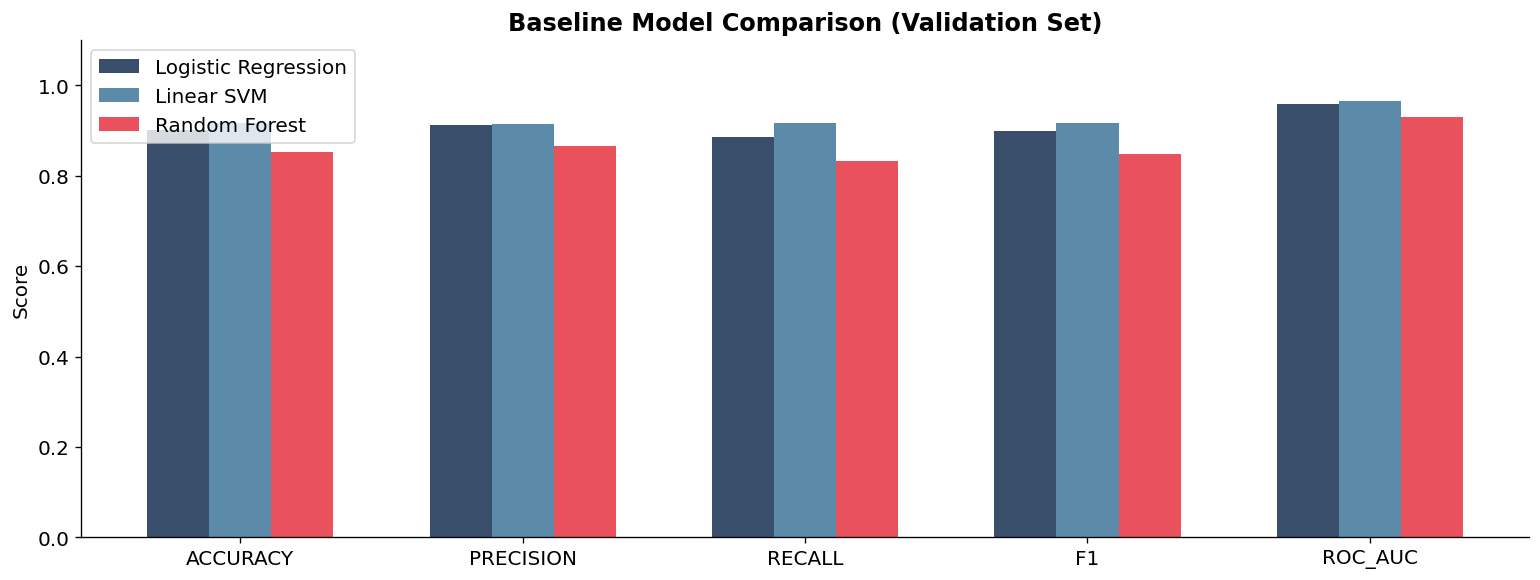

In [8]:
# Aggregate results
results_df = pd.DataFrame([lr_val, svm_val, rf_val])

# Display metrics
print(results_df[['model','accuracy','precision','recall','f1','roc_auc']]
      .round(4).to_string(index=False))


# Metrics for plotting
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics_to_plot))
width = 0.22

colors = ['#1D3557', '#457B9D', '#E63946']


# Plot comparison
fig, ax = plt.subplots(figsize=(13, 5))

for i, (_, row) in enumerate(results_df.iterrows()):
    ax.bar(
        x + (i - 1)*width,
        [row[m] for m in metrics_to_plot],
        width,
        label=row['model'],
        color=colors[i],
        alpha=0.88
    )

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison (Validation Set)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'baseline_model' / 'baseline_comparison.png',
            bbox_inches='tight')
plt.show()

## Best Model Selection and Test Evaluation

The best-performing model is selected based on the highest F1-score on the validation set, ensuring a balanced trade-off between precision and recall. This model is then evaluated on the test set to measure its performance on unseen data.

Finally, the trained model, along with the TF-IDF vectoriser and model metadata, is saved for reuse, and the evaluation results are exported for reporting and analysis.

Best baseline by F1: Linear SVM

── Linear SVM (Best) (test) ──
              precision    recall  f1-score   support

 non-suicide       0.91      0.90      0.90      1008
     suicide       0.90      0.91      0.90       990

    accuracy                           0.90      1998
   macro avg       0.90      0.90      0.90      1998
weighted avg       0.90      0.90      0.90      1998



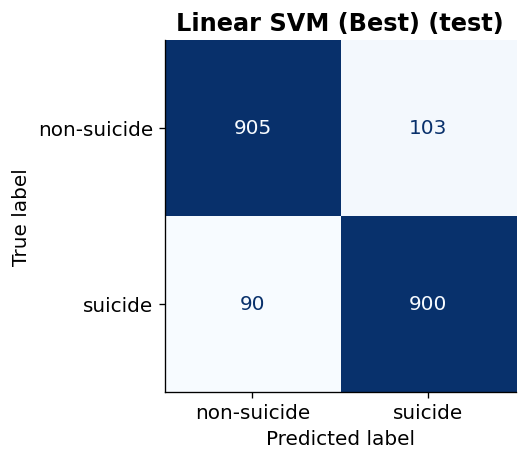

In [9]:
# Select best model based on validation F1-score
best_name = results_df.loc[results_df['f1'].idxmax(), 'model']

best_model_map = {
    'Logistic Regression': (lr,  X_test_tfidf),
    'Linear SVM':          (svm, X_test_tfidf),
    'Random Forest':       (rf,  X_test_aug),
}

best_model, X_test_best = best_model_map[best_name]

print(f'Best baseline by F1: {best_name}')


# Evaluate on test set
test_metrics = evaluate_model(
    best_model,
    X_test_best,
    y_test,
    best_name + ' (Best)',
    'test'
)


# Save best model
with open(BEST_BASELINE_PKL, 'wb') as f:
    pickle.dump({
        'model': best_model,
        'tfidf': tfidf,
        'name': best_name
    }, f)


# Save results
results_df.to_csv(BASELINE_RESULTS_CSV, index=False)